In [1]:
# https://drive.google.com/file/d/1jmtBO0m0L2wvZpTcpzk9ipIkFxlVe0AQ/view?usp=sharing # bands 2, 3, 4 and QA pixel cba clip
!gdown --id 1jmtBO0m0L2wvZpTcpzk9ipIkFxlVe0AQ

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1jmtBO0m0L2wvZpTcpzk9ipIkFxlVe0AQ
To: /content/stack_234QA_cg_clip.tif
100% 28.4M/28.4M [00:00<00:00, 50.0MB/s]


In [2]:
# INSTALL LIBRARIES AND DEPENDENCIES
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# OPEN AND EXTRACT BANDS DATA FROM IMAGE, AND STORE IN AN 3D NUMPY ARRAY
tif_path = '/content/stack_234QA_cg_clip.tif'

listBands_dn = []

with rasterio.open(tif_path) as src:
  profile = src.profile.copy()
  for b in range(1, src.read().shape[0]+1):
      listBands_dn.append(src.read(b))
arrayBands_dn = np.array(listBands_dn)

In [4]:
# CONVERT BANDS 2-4 DN DATA TO REFLECTANCE ACCORDING TO L8 SPECIFICATIONS

# --
arrayBands2to4_dn = arrayBands_dn.copy()[:3] # Exclude QA band

# --
arrayBands2to4_ref = (0.0000275*arrayBands2to4_dn- 0.2)
arrayBands2to4_ref = np.where(arrayBands2to4_ref < 0, np.nan, arrayBands2to4_ref)

In [5]:
#
qa = arrayBands_dn[-1]

# SET VALUES FOR CLOUDS AND CLOUD SHADOWS PIXELS (QGIS INSPECTION)
clouds_value = np.float32(22280)
#cloud_shadow_value = np.float32(21824)

# -
arrayBands2to4_ref = np.where(qa == clouds_value, np.nan, arrayBands2to4_ref)
#arrayBands2to4_ref = np.where(qa == cloud_shadow_value, np.nan, arrayBands2to4_ref)
# NOTE: Explore other approaches for QA masking, this is just exploratory

Text(0.5, 1.0, 'Band 1')

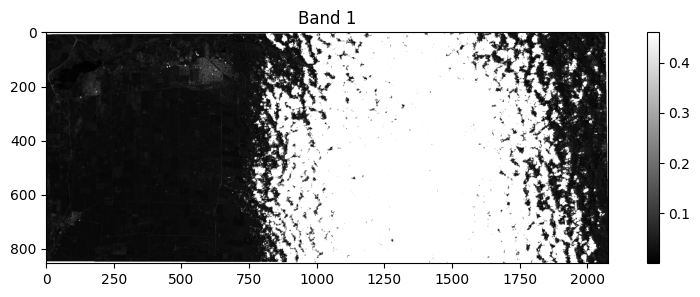

In [12]:
# PLOT BAND FOR VISUALIZE MASKING RESULT
band = 2 # choose from 2 to 4
i = band - 2

fig, ax = plt.subplots(figsize=(10, 3))

img = ax.imshow(arrayBands2to4_ref[i], cmap='gray')
fig.colorbar(img, ax=ax) # Correct way to add a colorbar
ax.set_title(f'Band {i+1}')

In [13]:
# UPDATE THE EXTRACTED ORIGINAL RASTER PROFILE, AND THEN SAVE THE GENERATED TIF WITH N REFLECTANCE BANDS

# Define output file name
outfile = 'stack_2to4Ref_masked.tif'

# Update profile
profile.update(
    tiled=True,
    blockxsize=256,  # Ensure blockxsize is a multiple of 16
    blockysize=256,  # Ensure blockysize is a multiple of 16
    count = arrayBands2to4_ref.shape[0],   # Use the correct number of bands after concatenation
)

# Write the output with the NDVI band
with rasterio.open(outfile, "w", **profile) as dst:
    # write original bands
    for i in range(arrayBands2to4_ref.shape[0]):
        dst.write(arrayBands2to4_ref[i], i + 1)